# <b>Inspection Data Classifier

Installing libraries

In [ ]:
!pip install -q \
    transformers==4.45.2 \
    datasets==3.0.1 \
    peft==0.13.2 \
    accelerate==1.0.1 \
    evaluate==0.4.3 \
    scikit-learn \
    pandas \
    numpy \
    torchmetrics

### Importing the Libraries

In [2]:
import torch
from torchmetrics import Accuracy
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from peft import LoraConfig, TaskType, get_peft_model
from datasets import load_dataset

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

### Import the dataset

In [66]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
DATASET_PATH = '/content/drive/MyDrive/MIRA/Datasets/coal_mine_inspections.csv'

In [68]:
dataset = load_dataset("csv", data_files = DATASET_PATH)
dataset

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['finding_text', 'issue', 'category', 'severity', 'recurring'],
        num_rows: 10000
    })
})

### Train-Test Splitting

In [9]:
dataset['train'][0]

{'finding_text': 'Lifeline directional indicators in Stope 9 East are missing over a length of 150 meters. Emergency refuge chamber battery backup system failed diagnostic test. Repeat violation: management failed to implement permanent remedy after prior notification.',
 'issue': 'Emergency Preparedness',
 'category': 'Mine Safety',
 'severity': 'High',
 'recurring': 'Yes'}

In [69]:
dataset['train'] = dataset['train'].class_encode_column('issue')
dataset['train'] = dataset['train'].class_encode_column('category')
dataset['train'] = dataset['train'].class_encode_column('severity')
dataset['train'] = dataset['train'].class_encode_column('recurring')

dataset['train']

Casting to class labels:   0%|          | 0/10000 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/10000 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/10000 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/10000 [00:00<?, ? examples/s]

Dataset({
    features: ['finding_text', 'issue', 'category', 'severity', 'recurring'],
    num_rows: 10000
})

In [70]:
dataset = dataset['train'].train_test_split(
    test_size=0.05,
    seed=42
)

dataset

DatasetDict({
    train: Dataset({
        features: ['finding_text', 'issue', 'category', 'severity', 'recurring'],
        num_rows: 9500
    })
    test: Dataset({
        features: ['finding_text', 'issue', 'category', 'severity', 'recurring'],
        num_rows: 500
    })
})

## Tokenization

In [71]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

In [72]:
def tokenize_function(examples):
    return tokenizer(examples['finding_text'], padding = 'max_length', truncation = True)

In [73]:
tokenized_dataset = dataset.map(tokenize_function, batched = True)

Map:   0%|          | 0/9500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [74]:
tokenized_dataset = tokenized_dataset.remove_columns(['finding_text'])

tokenized_dataset.set_format('torch')

In [75]:
print("Issue classes:", dataset['train'].features['issue'].names)
print("Category classes:", dataset['train'].features['category'].names)
print("Severity classes:", dataset['train'].features['severity'].names)
print("Recurring classes:", dataset['train'].features['recurring'].names)

Issue classes: ['Dust Suppression', 'Electrical Safety', 'Emergency Preparedness', 'Equipment Maintenance', 'Fire Safety', 'Haul Road', 'Personal Protective Equipment', 'Roof Support', 'Ventilation', 'Water Drainage']
Category classes: ['Electrical', 'Emergency Safety', 'Environment', 'Equipment Safety', 'Ground Control', 'Mine Safety', 'Safety']
Severity classes: ['Critical', 'High', 'Low', 'Medium']
Recurring classes: ['No', 'Yes']


In [76]:
num_issue = len(dataset['train'].features['issue'].names)
num_category = len(dataset['train'].features['category'].names)
num_severity = len(dataset['train'].features['severity'].names)
num_recurring = len(dataset['train'].features['recurring'].names)

print("Issue classes:", num_issue)
print("Category classes:", num_category)
print("Severity classes:", num_severity)
print("Recurring classes:", num_recurring)

Issue classes: 10
Category classes: 7
Severity classes: 4
Recurring classes: 2


## DataLoaders

In [77]:
train_dataloader = DataLoader(tokenized_dataset['train'], shuffle = True, batch_size = 8)
test_dataloader = DataLoader(tokenized_dataset['test'], batch_size = 8)

# Multi-Head Model

In [78]:
import torch
import torch.nn as nn

from transformers import DistilBertModel
from peft import LoraConfig, TaskType, get_peft_model

### MIRA Classifier

In [79]:
class MIRAClassifier(nn.Module):
    def __init__(self, num_issue, num_category, num_severity, num_recurring):
        super().__init__()

        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')

        hidden_size = self.distilbert.config.hidden_size

        # sub-models
        self.issue_classifier = nn.Linear(hidden_size, num_issue)
        self.category_classifier = nn.Linear(hidden_size, num_category)
        self.severity_classifier = nn.Linear(hidden_size, num_severity)
        self.recurring_classifier = nn.Linear(hidden_size, num_recurring)

    def forward(self, input_ids, attention_mask):
        outputs = self.distilbert(
            input_ids = input_ids,
            attention_mask = attention_mask
        )

        pooled_output = outputs.last_hidden_state[:, 0]

        issue_logits = self.issue_classifier(pooled_output)
        category_logits = self.category_classifier(pooled_output)
        severity_logits = self.severity_classifier(pooled_output)
        recurring_logits = self.recurring_classifier(pooled_output)

        return {
            'issue': issue_logits,
            'category': category_logits,
            'severity': severity_logits,
            'recurring': recurring_logits
        }

In [80]:
model = MIRAClassifier(num_issue, num_category, num_severity, num_recurring)

In [81]:
print(model)

MIRAClassifier(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Li

### LoRA

In [82]:
peft_config = LoraConfig(
    task_type = TaskType.FEATURE_EXTRACTION,
    r = 16,
    lora_alpha = 32,
    target_modules = ['q_lin', 'v_lin'],
    lora_dropout = 0.1,
    bias = 'none'
)

In [83]:
model.distilbert = get_peft_model(
    model.distilbert,
    peft_config
)

In [84]:
model.distilbert.print_trainable_parameters()

trainable params: 294,912 || all params: 66,657,792 || trainable%: 0.4424


In [85]:
device = 'cuda'
model.to(device)

MIRAClassifier(
  (distilbert): PeftModelForFeatureExtraction(
    (base_model): LoraModel(
      (model): DistilBertModel(
        (embeddings): Embeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (transformer): Transformer(
          (layer): ModuleList(
            (0-5): 6 x TransformerBlock(
              (attention): MultiHeadSelfAttention(
                (dropout): Dropout(p=0.1, inplace=False)
                (q_lin): lora.Linear(
                  (base_layer): Linear(in_features=768, out_features=768, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=16, bias=Fa

## Train Model

In [86]:
num_epochs = 3

num_training_steps = num_epochs * len(train_dataloader)

In [87]:
from torch.optim import AdamW

criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    model.parameters(),
    lr = 2e-5
)

lr_scheduler = LambdaLR (
    optimizer,
    lr_lambda = lambda current_step : (1 - current_step / num_training_steps)
)

In [88]:
def train_model(model, tr_dataloader):

    progress_bar = tqdm(range(num_training_steps))

    model.train()

    tr_losses = []

    for epoch in range(num_epochs):
        total_loss = 0
        for batch in tr_dataloader:
            batch = {
                k: v.to(device)
                for k, v in batch.items()
            }

            issue_labels = batch['issue']
            category_labels = batch['category']
            severity_labels = batch['severity']
            recurring_labels = batch['recurring']

            outputs = model(
                input_ids=batch['input_ids'],
                attention_mask=batch['attention_mask']
            )

            issue_loss = criterion(
                outputs['issue'],
                issue_labels
            )

            category_loss = criterion(
                outputs['category'],
                category_labels
            )

            severity_loss = criterion(
                outputs['severity'],
                severity_labels
            )

            recurring_loss = criterion(
                outputs['recurring'],
                recurring_labels
            )

            loss = (
                issue_loss +
                category_loss +
                severity_loss +
                recurring_loss
            )

            loss.backward()

            total_loss += loss.item()

            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()

            progress_bar.update(1)

        tr_losses.append(
            total_loss / len(tr_dataloader)
        )

    plt.plot(tr_losses)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

  0%|          | 0/3564 [00:00<?, ?it/s]

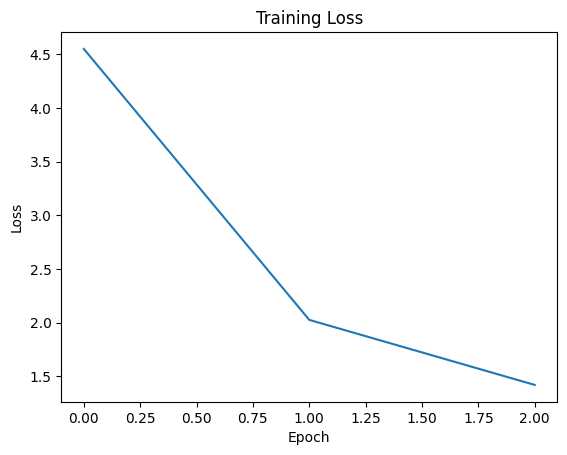

In [89]:
train_model(model, train_dataloader)

In [91]:
MODEL_PATH = '/content/drive/MyDrive/MIRA/models/mira-distilbert-lora'

### Saving LoRA adapter

In [92]:
model.distilbert.save_pretrained(MODEL_PATH)

### Save the four classification heads

In [93]:
import os

torch.save(
    {
        'issue_classifier': model.issue_classifier.state_dict(),
        'category_classifier': model.category_classifier.state_dict(),
        'severity_classifier': model.severity_classifier.state_dict(),
        'recurring_classifier': model.recurring_classifier.state_dict()
    },
    os.path.join(
        MODEL_PATH,
        'classification_heads.pth'
    )
)

### Saving the Label Mappings

In [94]:
import json

label_mappings = {
    'issue': dataset['train'].features['issue'].names,
    'category': dataset['train'].features['category'].names,
    'severity': dataset['train'].features['severity'].names,
    'recurring': dataset['train'].features['recurring'].names
}

with open(
    os.path.join(MODEL_PATH, 'label_mappings.json'),
    'w'
) as f:

    json.dump(
        label_mappings,
        f,
        indent=4
    )

---

# Inference Run

In [95]:
issue_names = tokenized_dataset['train'].features['issue'].names
category_names = tokenized_dataset['train'].features['category'].names
severity_names = tokenized_dataset['train'].features['severity'].names
recurring_names = tokenized_dataset['train'].features['recurring'].names

text = """
During inspection of the underground ventilation system, several ventilation
fans were found operating below the required airflow levels. Airflow
measurements in two working areas were below the prescribed standards.
Ventilation monitoring records were also incomplete for the previous month.
Similar deficiencies were identified during the previous inspection, and
corrective action has not yet been fully implemented.
"""

inputs = tokenizer(
    text,
    return_tensors='pt',
    truncation=True,
    padding=True
)

inputs = {
    k: v.to(device)
    for k, v in inputs.items()
}

model.eval()

with torch.no_grad():

    outputs = model(**inputs)

    issue_id = torch.argmax(
        outputs['issue'],
        dim=1
    ).item()

    category_id = torch.argmax(
        outputs['category'],
        dim=1
    ).item()

    severity_id = torch.argmax(
        outputs['severity'],
        dim=1
    ).item()

    recurring_id = torch.argmax(
        outputs['recurring'],
        dim=1
    ).item()

print("Predicted Issue:", issue_names[issue_id])
print("Predicted Category:", category_names[category_id])
print("Predicted Severity:", severity_names[severity_id])
print("Predicted Recurring:", recurring_names[recurring_id])

Predicted Issue: Ventilation
Predicted Category: Mine Safety
Predicted Severity: Medium
Predicted Recurring: Yes


---

---

# MIRA PDF-to-Classification Pipeline

In [ ]:
!pip install pymupdf

In [38]:
import os
import re
import json
import fitz
import torch
import torch.nn as nn

from transformers import AutoTokenizer, DistilBertModel
from peft import PeftModel

In [96]:
MODEL_PATH = '/content/drive/MyDrive/MIRA/models/mira-distilbert-lora'

In [97]:
class MIRAClassifier(nn.Module):

    def __init__(
        self,
        num_issue,
        num_category,
        num_severity,
        num_recurring
    ):

        super().__init__()

        self.distilbert = DistilBertModel.from_pretrained(
            'distilbert-base-uncased'
        )

        hidden_size = self.distilbert.config.hidden_size

        self.issue_classifier = nn.Linear(
            hidden_size,
            num_issue
        )

        self.category_classifier = nn.Linear(
            hidden_size,
            num_category
        )

        self.severity_classifier = nn.Linear(
            hidden_size,
            num_severity
        )

        self.recurring_classifier = nn.Linear(
            hidden_size,
            num_recurring
        )

    def forward(self, input_ids, attention_mask):

        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled_output = outputs.last_hidden_state[:, 0]

        issue_logits = self.issue_classifier(
            pooled_output
        )

        category_logits = self.category_classifier(
            pooled_output
        )

        severity_logits = self.severity_classifier(
            pooled_output
        )

        recurring_logits = self.recurring_classifier(
            pooled_output
        )

        return {
            'issue': issue_logits,
            'category': category_logits,
            'severity': severity_logits,
            'recurring': recurring_logits
        }

### Load Label Mappings

In [98]:
with open(
    os.path.join(
        MODEL_PATH,
        'label_mappings.json'
    ),
    'r'
) as f:

    label_mappings = json.load(f)

### Load Tokenizer

In [99]:
tokenizer = AutoTokenizer.from_pretrained(
    'distilbert-base-uncased'
)

### Model

In [100]:
model = MIRAClassifier(
    num_issue = len(label_mappings['issue']),
    num_category = len(label_mappings['category']),
    num_severity = len(label_mappings['severity']),
    num_recurring = len(label_mappings['recurring'])
)

### Load LoRA Adapter

In [101]:
model.distilbert = PeftModel.from_pretrained(
    model.distilbert,
    MODEL_PATH
)

### Load Classification Heads

In [102]:
heads = torch.load(
    os.path.join(
        MODEL_PATH,
        'classification_heads.pth'
    ),
    map_location='cpu'
)

In [103]:
model.issue_classifier.load_state_dict(
    heads['issue_classifier']
)

model.category_classifier.load_state_dict(
    heads['category_classifier']
)

model.severity_classifier.load_state_dict(
    heads['severity_classifier']
)

model.recurring_classifier.load_state_dict(
    heads['recurring_classifier']
)

<All keys matched successfully>

### Set Device

In [104]:
device = torch.device(
    'cuda'
    if torch.cuda.is_available()
    else 'cpu'
)

model.to(device)

model.eval()

print("Device:", device)

Device: cuda


---

## PDF Processing

In [105]:
PDF_PATH = '/content/drive/MyDrive/MIRA/Inspection Reports/Coal_Mine_Inspection_Report_Concise.pdf'

### Extract Text from PDF

In [106]:
def extract_pdf_text(pdf_path):

    document = fitz.open(
        pdf_path
    )

    text = ""

    for page in document:

        text += page.get_text()

    document.close()

    return text

In [114]:
def extract_findings(text):

    pattern = r'Finding\s+(F-\d+):\s*(.*?)(?=Finding\s+F-\d+:|(?:\n|\s)5\.\s*INSPECTOR[\'’]?S\s+REMARKS|$)'

    matches = re.findall(
        pattern,
        text,
        flags=re.DOTALL | re.IGNORECASE
    )

    findings = []

    for finding_id, finding_text in matches:

        findings.append({
            'finding_id': finding_id,
            'finding_text': finding_text.strip()
        })

    return findings

### MIRA Classification

In [108]:
def classify_finding(text):

    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask']
        )

    issue_id = torch.argmax(
        outputs['issue'],
        dim=1
    ).item()

    category_id = torch.argmax(
        outputs['category'],
        dim=1
    ).item()

    severity_id = torch.argmax(
        outputs['severity'],
        dim=1
    ).item()

    recurring_id = torch.argmax(
        outputs['recurring'],
        dim=1
    ).item()

    return {
        'issue': label_mappings['issue'][issue_id],
        'category': label_mappings['category'][category_id],
        'severity': label_mappings['severity'][severity_id],
        'recurring': label_mappings['recurring'][recurring_id]
    }

In [115]:
pdf_text = extract_pdf_text(PDF_PATH)

print(pdf_text)

GOVERNMENT OF INDIA
MINISTRY OF COAL
DIRECTORATE OF MINES SAFETY
COAL MINE INSPECTION REPORT
SYNTHETIC PROTOTYPE DOCUMENT — FOR AI/ML PROTOTYPE DEVELOPMENT ONLY
Inspection Report No.
DMS/WR/2026/8347
Inspection Date
18 July 2026
Report Date
22 July 2026
Mine ID
MH-CM-047
Mine Name
Bhiravadi Coal Mine, Zone-B
Operator
Bhiravadi Mining Corporation Ltd.
Inspection Type
Periodic Safety Inspection
1. MINE DETAILS
State
Maharashtra
District
Chandrapur
Village
Bhiravadi, Taluka: Ballarpur
Coordinates
19.9156° N, 79.3842° E
Mining Method
Underground Bord and Pillar
Mine Status
Active
Working Depth
220 – 280 meters below surface
2. INSPECTING OFFICER
Inspector Name
Shri Ajay Verma
Designation
Deputy Chief Inspector of Mines
Regional Office
DMS Western Region, Nagpur
Inspection Team
Shri Pradeep Kumar (Safety Engineer)
Inspection Duration
18 – 20 July 2026
3. AREAS INSPECTED
Eastern working panel (Level -2), main haul road (surface), heavy equipment workshop, primary electrical substation,
emerg

### Extract Findings

In [116]:
findings = extract_findings(
    pdf_text
)

print(
    "Number of findings:",
    len(findings)
)

Number of findings: 6


<b>Checking the findings</b><br>
Don't show this or use this in the backend. This is completely for the AI team to understand the working.

In [117]:
for finding in findings:

    print("\n" + "=" * 70)

    print(
        finding['finding_id']
    )

    print(
        finding['finding_text']
    )


F-01
During inspection of the eastern working panel at Level -2, inadequate air circulation was observed in areas remote from the
main ventilation inlet. Real-time airflow measurements showed 1.9 m/s against a minimum requirement of 2.5 m/s. The
ventilation ducting in this section exhibits visible wear and multiple seams. This deficiency has been recorded in the
inspection report from the preceding inspection period, indicating that earlier recommendations for duct replacement have not
been implemented.

F-02
Examination of the roof support system in the active working panel revealed significant deterioration of installed rock bolts.
Structural integrity tests indicated that approximately 12 out of 60 bolts inspected show corrosion-induced loss of tensile
strength. No roof fall incidents have occurred to date, however this represents a critical stability concern requiring immediate
remedial intervention to prevent potential hazards.

F-03
The Load-Haul-Dump (LHD) equipment in the unde

### Classify Every Finding

In [118]:
results = []

for finding in findings:

    prediction = classify_finding(
        finding['finding_text']
    )

    results.append({
        'finding_id': finding['finding_id'],
        'finding_text': finding['finding_text'],
        'issue': prediction['issue'],
        'category': prediction['category'],
        'severity': prediction['severity'],
        'recurring': prediction['recurring']
    })

### Display Final Results

In [119]:
for result in results:

    print("\n" + "=" * 70)

    print(
        "Finding:",
        result['finding_id']
    )

    print(
        "\nFinding Text:"
    )

    print(
        result['finding_text']
    )

    print(
        "\nIssue:",
        result['issue']
    )

    print(
        "Category:",
        result['category']
    )

    print(
        "Severity:",
        result['severity']
    )

    print(
        "Recurring:",
        result['recurring']
    )


Finding: F-01

Finding Text:
During inspection of the eastern working panel at Level -2, inadequate air circulation was observed in areas remote from the
main ventilation inlet. Real-time airflow measurements showed 1.9 m/s against a minimum requirement of 2.5 m/s. The
ventilation ducting in this section exhibits visible wear and multiple seams. This deficiency has been recorded in the
inspection report from the preceding inspection period, indicating that earlier recommendations for duct replacement have not
been implemented.

Issue: Ventilation
Category: Mine Safety
Severity: Medium
Recurring: Yes

Finding: F-02

Finding Text:
Examination of the roof support system in the active working panel revealed significant deterioration of installed rock bolts.
Structural integrity tests indicated that approximately 12 out of 60 bolts inspected show corrosion-induced loss of tensile
strength. No roof fall incidents have occurred to date, however this represents a critical stability concern re